## Detección de anomalías

Los transformadores juegan un papel muy importante en el sistema eléctrico. Aunque son algunos de los componentes más confiables de la red eléctrica, también son propensos a fallar debido a muchos factores, tanto internos como externos. Podría haber muchos iniciadores que causen una falla en el transformador, pero los que potencialmente pueden conducir a una falla catastrófica son los siguientes:
Falla mecánica
Falla dieléctrica

Contenido
Estos datos se recopilaron a través de dispositivos IoT desde el 25 de junio de 2019 hasta el 14 de abril de 2020 y se actualizaron cada 15 minutos.
El dataset contiene 19352 registros.
Descripción de los parámetros:
Voltaje de corriente:
1. VL1- Fase Línea 1
2. VL2- Fase Línea 2
3. VL3- Fase Línea 3
4. IL1- Línea actual 1
5. IL2- Línea actual 2
6. IL3- Línea actual 3
7. VL12- Línea de tensión 1 2
8. VL23- Línea de tensión 2 3
9. VL31- Línea de tensión 3 1
10. INUT-Corriente neutra

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# se carga el dataset, con separados ;, se transforman las dos columnas Date y Time a una única columna con tipo datetime
# en el fichero CSV existen NaN identificados por ?
df = pd.read_csv('CurrentVoltage.csv', sep=',', na_values='?')

#### ¿Cuántas instancias tiene el dataset?

In [ ]:
df.shape[0]

19352

#### ¿Cuál es el tipo de datos predominante en las variables?

In [ ]:
df.head()

,DeviceTimeStamp,VL1,VL2,VL3,IL1,IL2,IL3,VL12,VL23,VL31,INUT
0,2019-06-25T13:06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-06-27T10:49,238.7,238.7,238.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-06-27T10:51,238.4,238.5,238.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-06-27T10:52,239.9,240.0,240.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019-06-27T10:52,239.9,240.0,240.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.dtypes.value_counts()

,count
float64,10
object,1


## Variables nulas

No tiene datos faltantes.

In [ ]:
df.isnull().sum()

,0
DeviceTimeStamp,0
VL1,0
VL2,0
VL3,0
IL1,0
IL2,0
IL3,0
VL12,0
VL23,0
VL31,0


#### ¿Es necesario hacer algún tratamiendo adicional sobre los datos?

In [ ]:
from sklearn.preprocessing import StandardScaler

# Eliminamos registros duplicados
df.drop_duplicates(inplace=True)

# Normalizamos
#scaler = StandardScaler()
#numeric_cols = df.select_dtypes(include=['float64']).columns
#df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.describe()

,VL1,VL2,VL3,IL1,IL2,IL3,VL12,VL23,VL31,INUT
count,19320.000000,19320.000000,19320.000000,19320.000000,19320.000000,19320.000000,19320.000000,19320.000000,19320.000000,19320.000000
mean,241.069151,240.515538,239.911351,73.832935,59.068256,83.364394,380.103830,379.153219,380.598659,26.358773
std,9.543768,9.808790,8.853003,41.181669,40.426082,43.513627,119.063255,118.517265,119.173345,15.077719
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,235.400000,235.100000,235.100000,46.900000,31.600000,56.400000,400.800000,401.400000,402.000000,16.900000
50%,242.700000,242.100000,241.100000,69.600000,50.200000,80.300000,417.800000,416.300000,418.000000,25.600000
75%,247.500000,246.700000,245.300000,100.100000,82.600000,114.025000,427.500000,425.300000,427.600000,35.800000
max,261.200000,261.300000,261.300000,224.100000,253.600000,247.300000,446.500000,444.800000,447.300000,145.800000


#### Media móvil

In [ ]:
# Vamos a aplicar la técnica de detección de anomalías de Media Móvil sobre la variable INUT

In [ ]:
# Calcula la media móvil
window_size = 10 # ventana de la media móvil

# Media y desviación estándar móviles
rolling_mean = df['INUT'].rolling(window=window_size).mean()
rolling_std  = df['INUT'].rolling(window=window_size).std()

In [ ]:
# Define un umbral para detectar anomalías
mm_threshold = 2
df['anomaly_mm'] = (df['INUT'] - rolling_mean).abs() > mm_threshold * rolling_std

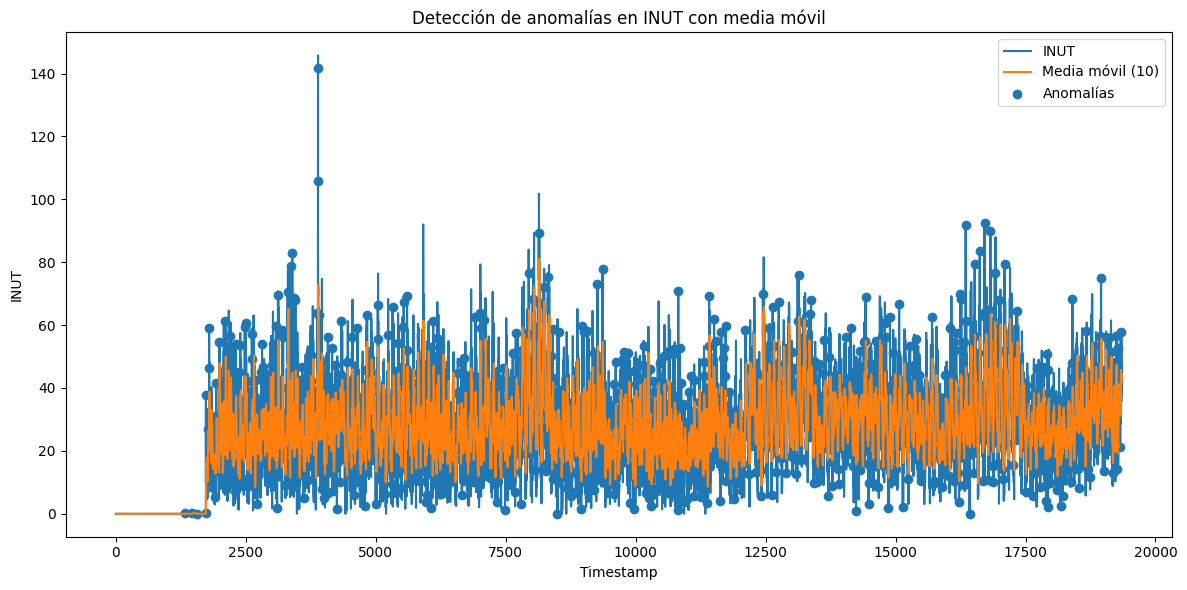

In [ ]:
# Visualiza los resultados
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['INUT'], label='INUT')
plt.plot(rolling_mean.index, rolling_mean, label=f'Media móvil ({window_size})')
plt.scatter(df.index[df['anomaly_mm']], df['INUT'][df['anomaly_mm']], label='Anomalías', marker='o')
plt.title('Detección de anomalías en INUT con media móvil')
plt.xlabel('Timestamp')
plt.ylabel('INUT')
plt.legend()
plt.tight_layout()
plt.show()

#### Z-Score

In [ ]:
# Vamos a aplicar la técnica de detección de anomalías Z-Score
mean_val = df['INUT'].mean()
std_val = df['INUT'].std()

df['z_score'] = (df['INUT'] - mean_val) / std_val

In [ ]:
# Define un umbral para detectar anomalías (por ejemplo, 3 desviaciones estándar)
z_threshold = 3
df['anomaly_z'] = df['z_score'].abs() > z_threshold

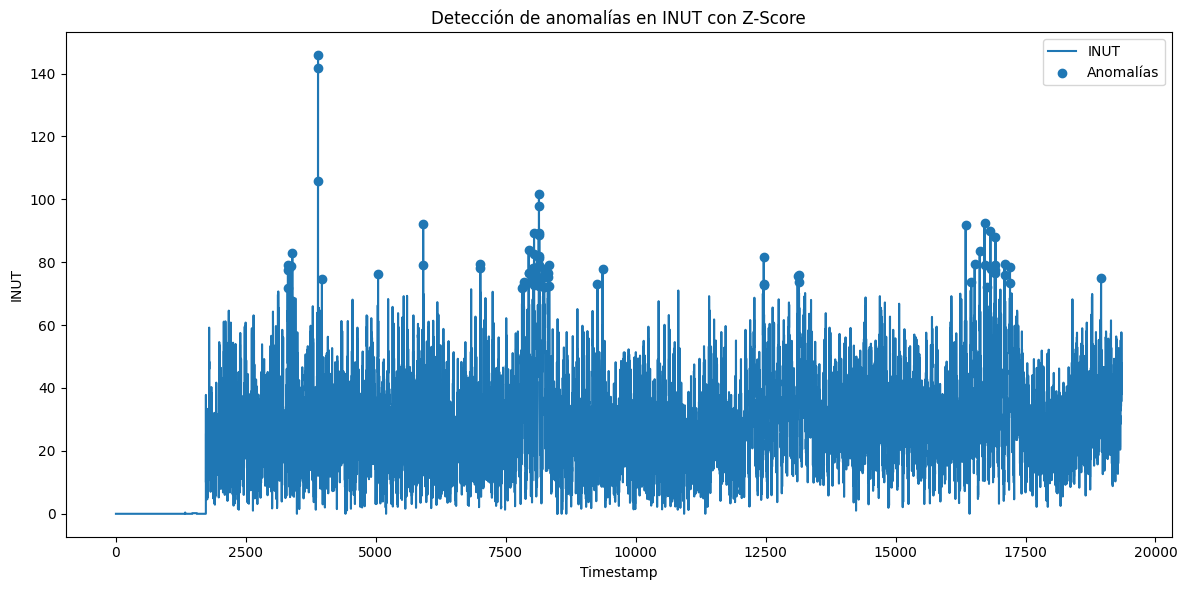

In [ ]:
# Visualiza los resultados
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['INUT'], label='INUT')
plt.scatter(df.index[df['anomaly_z']], df['INUT'][df['anomaly_z']], label='Anomalías', marker='o')
plt.title('Detección de anomalías en INUT con Z-Score')
plt.xlabel('Timestamp')
plt.ylabel('INUT')
plt.legend()
plt.tight_layout()
plt.show()

#### Isolation Forest

In [ ]:
# Vamos a aplicar la técnica de detección de anomalías de Isolation Forest, configura el parámetro contamination en 5%
from sklearn.ensemble import IsolationForest

iso_05 = IsolationForest(contamination=0.05, random_state=42)
iso_05.fit(df[['INUT']])

IsolationForest(contamination=0.05, random_state=42)

In [ ]:
# Agrega las columnas de puntaje y si es dato anómalo o no en el dataframe
df['score_iforest_05'] = iso_05.decision_function(df[['INUT']])
labels_05 = iso_05.predict(df[['INUT']])
df['anomaly_05'] = labels_05 == -1

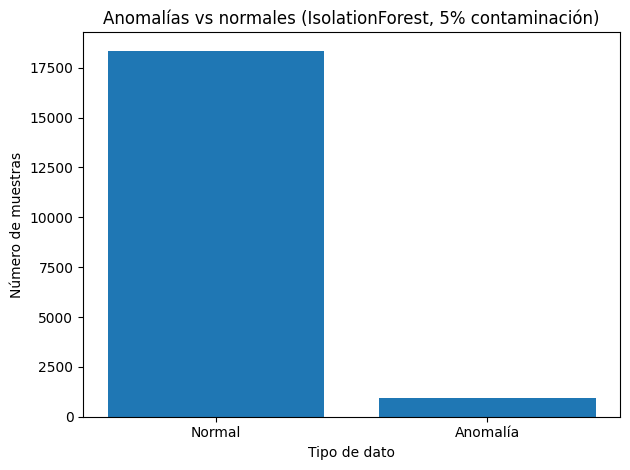

In [ ]:
# Crea un gráfico de barras para mostrar los datos anómalos vs los datos normales
counts_05 = df['anomaly_05'].value_counts()
normal_count_05 = counts_05.get(False, 0)
anom_count_05 = counts_05.get(True, 0)

plt.figure()
plt.bar(['Normal', 'Anomalía'], [normal_count_05, anom_count_05])
plt.title('Anomalías vs normales (IsolationForest, 5% contaminación)')
plt.xlabel('Tipo de dato')
plt.ylabel('Número de muestras')
plt.tight_layout()

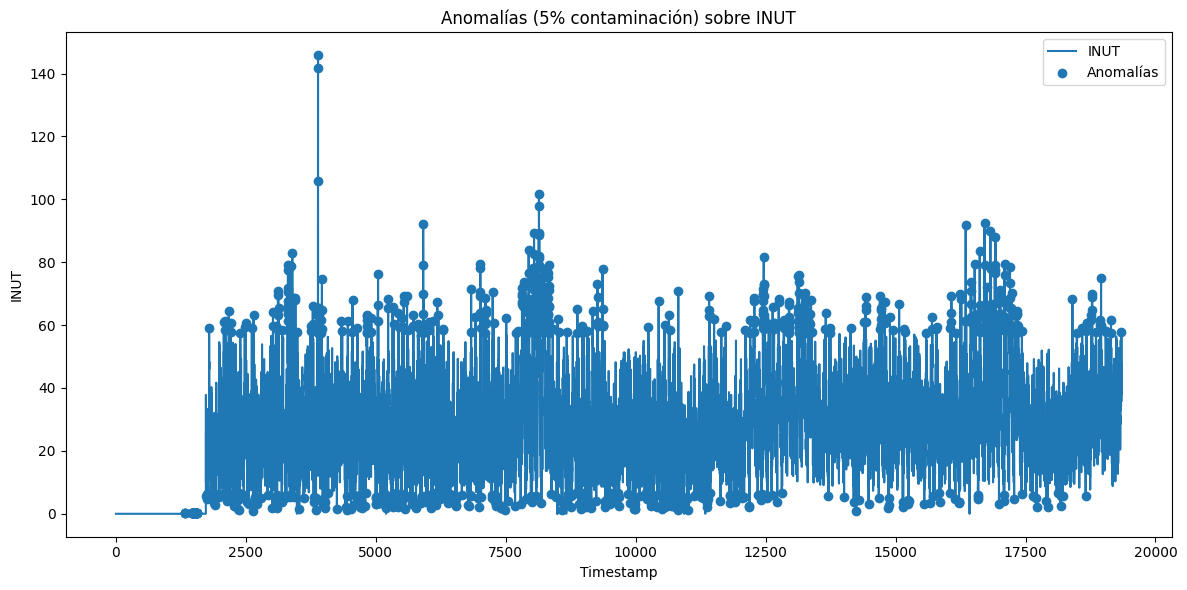

In [ ]:
# Crea un gráfico donde se puedan ver los datos anómalos sobre la variable INUT.
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['INUT'], label='INUT')
plt.scatter(df.index[df['anomaly_05']], df['INUT'][df['anomaly_05']], label='Anomalías', marker='o')
plt.title('Anomalías (5% contaminación) sobre INUT')
plt.xlabel('Timestamp')
plt.ylabel('INUT')
plt.legend()
plt.tight_layout()

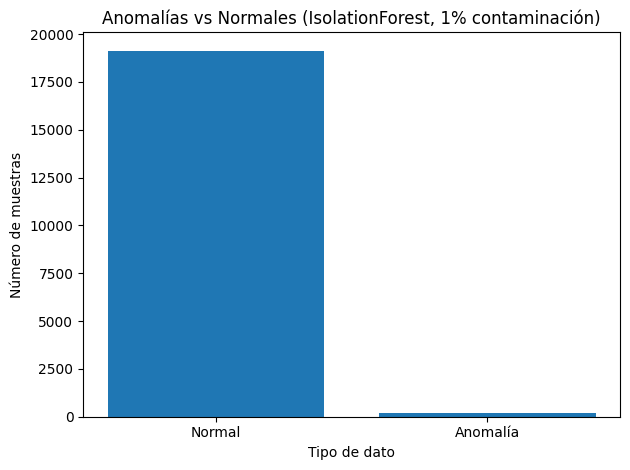

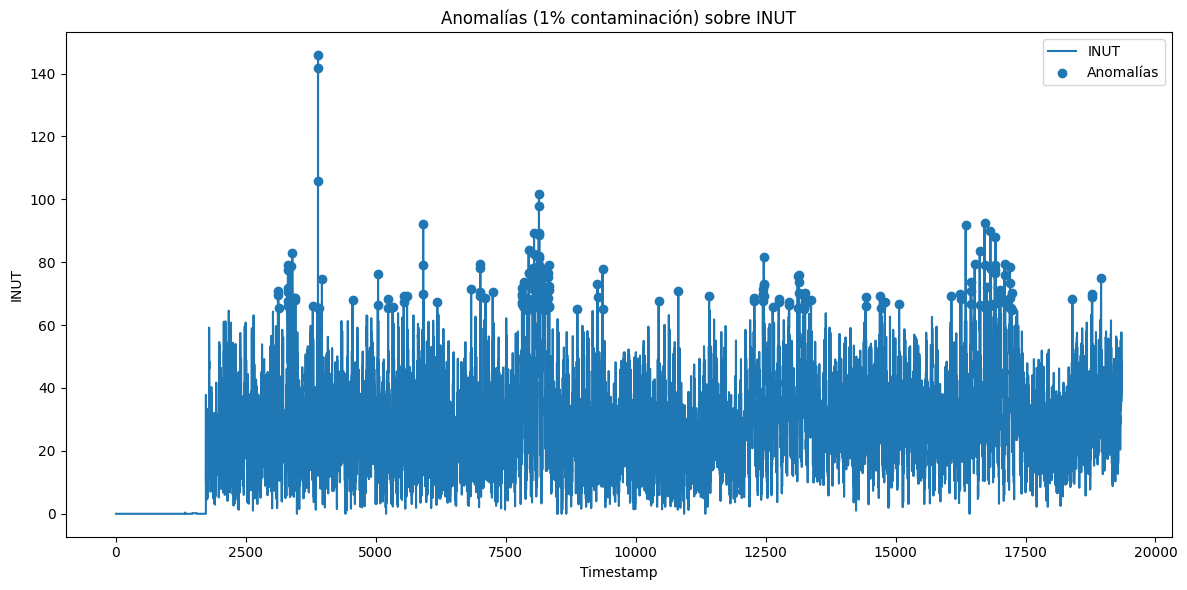

In [ ]:
# Repite los pasos anteriores con el parámetro de contamination en 1%
iso_01 = IsolationForest(contamination=0.01, random_state=42)
iso_01.fit(df[['INUT']])
df['score_iforest_01'] = iso_01.decision_function(df[['INUT']])
labels_01 = iso_01.predict(df[['INUT']])
df['anomaly_01'] = labels_01 == -1

# Gráfico de barras: datos anómalos vs datos normales (1%)
counts_01 = df['anomaly_01'].value_counts()
normal_count_01 = counts_01.get(False, 0)
anom_count_01 = counts_01.get(True, 0)

plt.figure()
plt.bar(['Normal', 'Anomalía'], [normal_count_01, anom_count_01])
plt.title('Anomalías vs Normales (IsolationForest, 1% contaminación)')
plt.xlabel('Tipo de dato')
plt.ylabel('Número de muestras')
plt.tight_layout()

# Gráfico de anomalías sobre INUT (1%)
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['INUT'], label='INUT')
plt.scatter(df.index[df['anomaly_01']], df['INUT'][df['anomaly_01']], label='Anomalías', marker='o')
plt.title('Anomalías (1% contaminación) sobre INUT')
plt.xlabel('Timestamp')
plt.ylabel('INUT')
plt.legend()
plt.tight_layout()

## Local Outlier Factor

In [ ]:
# Vamos a aplicar la técnica de detección de anomalías de Local Outlier Factor
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

labels = lof.fit_predict(df[['INUT']])
df['lof_score']   = lof.negative_outlier_factor_
df['anomaly_lof'] = labels == -1

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


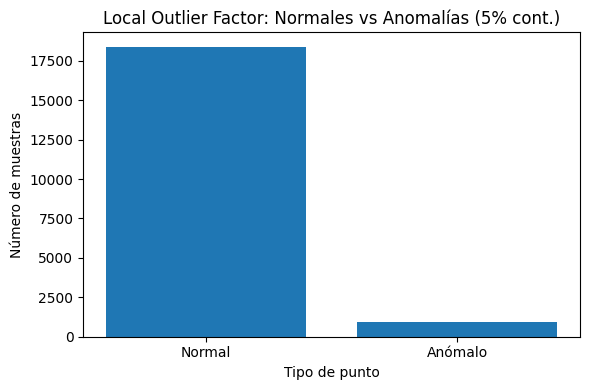

In [ ]:
# Crea un gráfico de barras para mostrar los datos anómalos vs los datos normales
counts = df['anomaly_lof'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Normal', 'Anómalo'], [counts.get(False, 0), counts.get(True, 0)])
plt.title('Local Outlier Factor: Normales vs Anomalías (5% cont.)')
plt.xlabel('Tipo de punto')
plt.ylabel('Número de muestras')
plt.tight_layout()

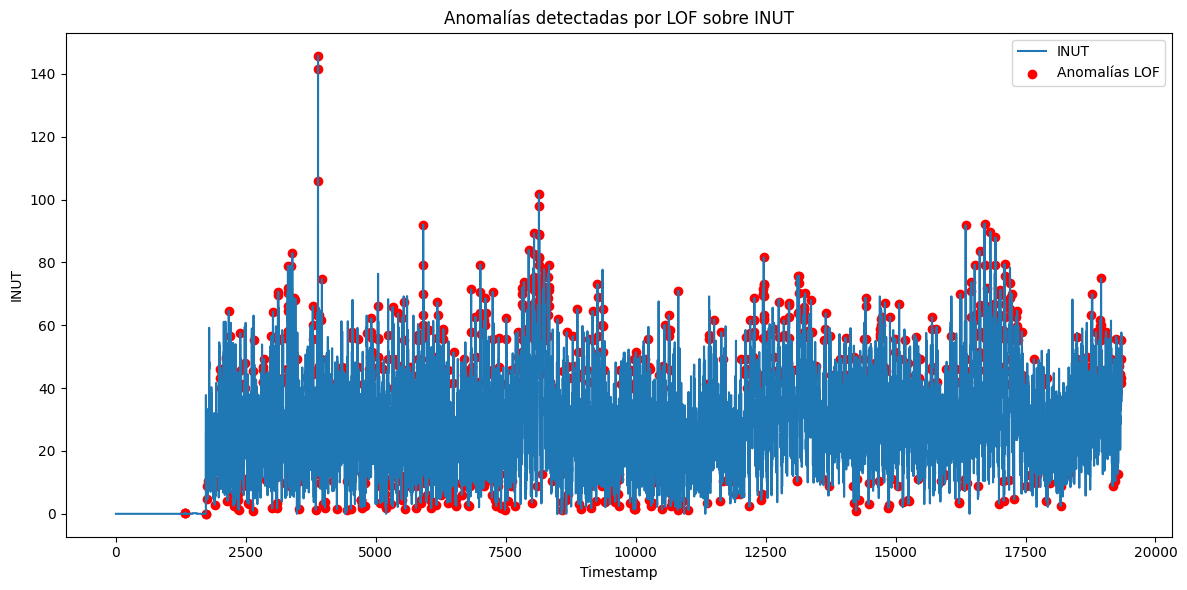

In [ ]:
# Crea un gráfico donde se puedan ver los datos anómalos sobre la variable INUT.
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['INUT'], label='INUT')
plt.scatter(df.index[df['anomaly_lof']], df['INUT'][df['anomaly_lof']],
            color='red', label='Anomalías LOF', marker='o')
plt.title('Anomalías detectadas por LOF sobre INUT')
plt.xlabel('Timestamp')
plt.ylabel('INUT')
plt.legend()
plt.tight_layout()

## Análisis

               metodo  anomalias_count  porcentaje
0         Media móvil              687    3.555901
1             Z-Score               72    0.372671
2  IsolationForest 5%              963    4.984472
3  IsolationForest 1%              189    0.978261
4              LOF 5%              933    4.829193


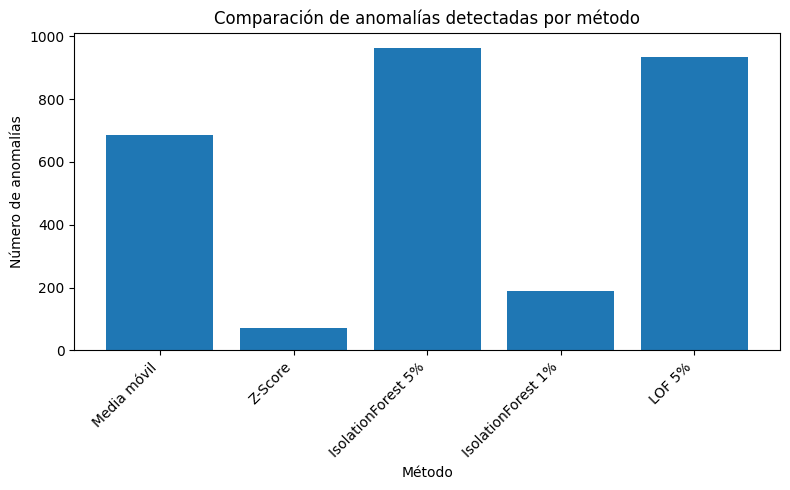

In [ ]:
n = len(df)

mm_count = df['anomaly_mm'].sum()
z_count = df['anomaly_z'].sum()
if05_count = df['anomaly_05'].sum()
if01_count = df['anomaly_01'].sum()
lof_count = df['anomaly_lof'].sum()

summary_df = pd.DataFrame({
    'metodo': ['Media móvil', 'Z-Score', 'IsolationForest 5%', 'IsolationForest 1%', 'LOF 5%'],
    'anomalias_count': [mm_count, z_count, if05_count, if01_count, lof_count]
})
summary_df['porcentaje'] = 100 * summary_df['anomalias_count'] / n
print(summary_df)

# Gráfico comparativo de recuento de anomalías por método
plt.figure(figsize=(8, 5))
plt.bar(summary_df['metodo'], summary_df['anomalias_count'])
plt.xlabel('Método')
plt.ylabel('Número de anomalías')
plt.title('Comparación de anomalías detectadas por método')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Media móvil (ventana=10, umbral=2σ)

- Detectó 687 anomalías/outliers (~3.56% del total).

Tiende a marcar picos locales que se desvían rápidamente de su promedio de ventana, es un método útil para identificar saltos abruptos y caídas temporales, aunque puede pasar por alto anomalías dispersas de menor magnitud si quedan dentro de la variabilidad de la ventana.

### Z-Score (umbral=3σ)

- Detectó 72 anomalías (~0.37%).

Como evalúa respecto a la media global, sólo resalta los valores más extremos de toda la serie, ignorando picos moderados que sean "normales" dentro de picos de menor escala. Por tanto, es un método más conservador, más adecuado cuando sólo interesa detectar verdaderos extremos.

### Isolation Forest

- 5% contaminación: detectó 963 anomalías (~4.98%).
- 1% contaminación: redujo drásticamente las anomalías detectadas a 189 (~0.98%).

Extrae patrones basados en particionado y profundidad de aislamiento, detectando anomalías globales y locales. La diferencia muestra como este método cambia su sensibilidad ante anomalías menores al bajar la contaminación.

### Local Outlier Factor (5%)

- Detectó 933 anomalías (~4.83%).

LOF basa su criterio en densidad local, resaltando puntos en regiones de baja densidad de datos, lo que tiende a capturar anomalías moderadas en zonas menos concurridas.

A menudo encuentra más outliers en los bordes de grupos de datos, no solo en extremos absolutos.

### Conclusiones

Cada uno de los métodos aplicados sobre el dataset se adecua mejor para la detección de cierto tipo de anomalías.

Media móvil es muy eficaz para la detección de picos locales con saltos abruptos en la media circundante.

Para detectar extremos globales, Z-Score o IsolationForest con una baja contaminación (1%) funcionan mejor, eliminando falsos positivos.

Si el objetivo es detectar anomalías de densidad, LOF sería un método adecuado.

Isolation Forest permite ajustar su sensibilidad de manera precisa, combinando características globales y locales.

Finalmente, cabe mencionar que la combinación de varios métodos de detección de anomalías permitiría cubrir distintos tipos de anomalías. Además, para mejorar la robustez del sistema, sería útil implementar un sistema de votación entre diferentes métodos de detección, reduciendo así la detección de falsos positivos.

